### Phase 5: OCR + Layout Fusion
**Objective**: Run YOLO layout detection and Tesseract OCR simultaneously. Associate OCR tokens with detected layout regions using center-point containment.

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys
import cv2
import json
import matplotlib.pyplot as plt

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.preprocessing.pipeline import render_pdf_page, to_grayscale, apply_clahe, otsu_threshold
from src.ocr.ocr_engine import extract_text_and_boxes

from ultralytics import YOLO

print("All modules imported successfully.")

All modules imported successfully.


In [2]:
model_path = "../models/layout_detection_exp/weights/best.pt"
model = YOLO(model_path)

pdf_path = "../data/raw/1706.03762v7.pdf"
original_img = render_pdf_page(pdf_path, page_num = 0, dpi = 300)
gray = to_grayscale(original_img)
clahe = apply_clahe(gray)
preprocessed_img = otsu_threshold(clahe)

print("Running YOLO layout detection")
yolo_results = model(original_img, verbose=False)
yolo_boxes = yolo_results[0].boxes

print("Running tesseract OCR")
ocr_tokens = extract_text_and_boxes(preprocessed_img)

print(f"Detected {len(yolo_boxes)} layout regions \n {len(ocr_tokens)} OCR tokens.")

Running YOLO layout detection
Running tesseract OCR
Detected 9 layout regions 
 399 OCR tokens.


In [3]:
def calculate_overlap_area(boxA, boxB):
    """
    Calculate the intersection area between two bounding boxes."""
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interWidth = max(0, xB - xA)
    interHeight = max(0, yB - yA)
    return interWidth * interHeight

def fuse_ocr_and_layout(yolo_results, ocr_tokens):
    """
    Associates OCR tokens with YOLO layout regions using Maximum Overlap Area 
    """
    layout_regions = []

    for box in yolo_results[0].boxes:
        cls_id = int(box.cls[0].item())
        cls_name = model.names[cls_id]
        conf = float(box.conf[0].item())
        x1, y1, x2, y2 = [int(v) for v in box.xyxy[0].tolist()]

        layout_regions.append({
            "label" : cls_name,
            "bbox": [x1, y1, x2, y2],
            "confidence": conf,
            "text": []
        })

    for token in ocr_tokens:
        token_bbox = token['bbox']
        best_region = None
        max_overlap = 0
        
        # Check which layout region has the maximum overlap with the token
        for region in layout_regions:
            overlap = calculate_overlap_area(token_bbox, region['bbox'])

            if overlap > max_overlap:
                max_overlap  = overlap
                best_region = region

        if best_region and max_overlap > 0:
            best_region['text'].append(token['text'])

    for region in layout_regions:
        region['text'] = ' '.join(region['text'])
        
    return layout_regions

# Run the fusion
document_structure = fuse_ocr_and_layout(yolo_results, ocr_tokens)
print(json.dumps(document_structure[:5], indent=4))

[
    {
        "label": "Text",
        "bbox": [
            591,
            1726,
            1959,
            2401
        ],
        "confidence": 0.9823603630065918,
        "text": "The dominant sequence transduction models are based on complex recurrent or convolutional neural networks that include an encoder and a decoder. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convolutions entirely. Experiments on two machine translation tasks show these models to be superior in quality while being more parallelizable and requiring significantly less time to train. Our model achieves 28.4 BLEU on the WMT 2014 English- to-German translation task, improving over the existing best results, including ensembles, by over 2 BLEU. On the WMT 2014 English-to-French translation task, our model establishes a new sin

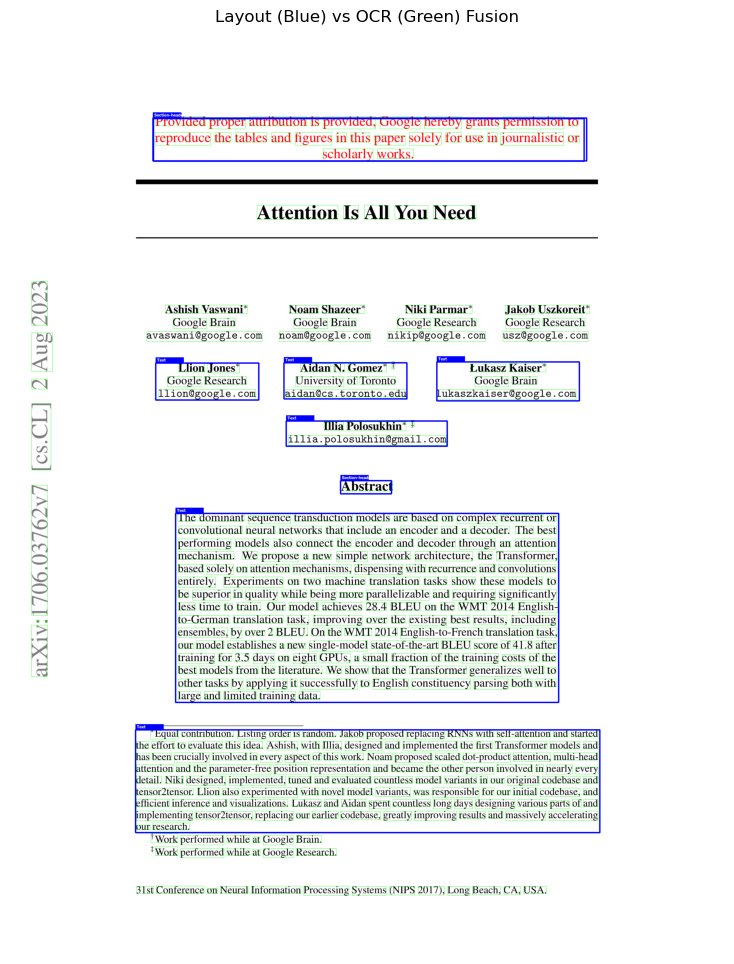

In [4]:
def draw_fusion(image, layout_regions):
    """Draws YOLO boxes in Blue and OCR boxes in Green."""
    img_copy = image.copy()
    
    # Draw OCR boxes (Green, thin)
    for token in ocr_tokens:
        tx1, ty1, tx2, ty2 = token['bbox']
        cv2.rectangle(img_copy, (tx1, ty1), (tx2, ty2), (0, 255, 0), 1)
    
    # Draw Layout regions (Blue, thick) and Labels
    for region in layout_regions:
        rx1, ry1, rx2, ry2 = region['bbox']
        
        cv2.rectangle(img_copy, (rx1, ry1), (rx2, ry2), (255, 0, 0), 3)
        
        # Put label text above the box
        cv2.rectangle(img_copy, (rx1, ry1 - 20), (rx1 + 100, ry1), (255, 0, 0), -1)
        cv2.putText(img_copy, region['label'], (rx1 + 5, ry1 - 5), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)
        
    return img_copy

# Draw and display
fusion_img = draw_fusion(original_img, document_structure)

plt.figure(figsize=(12, 12))
plt.imshow(cv2.cvtColor(fusion_img, cv2.COLOR_BGR2RGB))
plt.title("Layout (Blue) vs OCR (Green) Fusion")
plt.axis('off')
plt.show()

### Phase 6: Reading-Order Reconstruction
**Objective**: Sort the fused layout regions into a logical reading order (top-to-bottom, column-by-column).

In [5]:
def merge_nearby_regions(regions, x_gap_threshold=50, y_gap_threshold=20):
    """
    Merges tiny fragmented regions of the same label into larger paragraph blocks.
    """
    if not regions:
        return []
        
    # Sort by Y, then X to start grouping
    regions = sorted(regions, key=lambda r: (r['bbox'][1], r['bbox'][0]))
    merged = [regions[0]]
    
    for current in regions[1:]:
        last = merged[-1]
        
        # Check if they have the same label
        if current['label'] == last['label']:
            # Calculate horizontal and vertical gaps between last and current
            last_x2 = last['bbox'][2]
            current_x1 = current['bbox'][0]
            x_gap = current_x1 - last_x2
            
            last_y2 = last['bbox'][3]
            current_y1 = current['bbox'][1]
            y_gap = current_y1 - last_y2
            
            # If they are close enough horizontally and vertically, merge them
            if abs(x_gap) < x_gap_threshold and y_gap < y_gap_threshold:
                # Merge bounding boxes
                new_x1 = min(last['bbox'][0], current['bbox'][0])
                new_y1 = min(last['bbox'][1], current['bbox'][1])
                new_x2 = max(last['bbox'][2], current['bbox'][2])
                new_y2 = max(last['bbox'][3], current['bbox'][3])
                
                last['bbox'] = [new_x1, new_y1, new_x2, new_y2]
                last['text'] += " " + current['text']
                continue # Skip adding current as a new region
                
        merged.append(current)
        
    return merged

def sort_reading_order(regions, page_width=2400):
    """
    Sorts regions assuming a 2-column layout.
    Assigns regions to Column 0 (Left) or Column 1 (Right) based on page center.
    """
    if not regions:
        return []

    # 1. Determine page midpoint (you can adjust this if your document is narrower)
    mid_x = page_width / 2

    left_col = []
    right_col = []

    # 2. Assign to columns based on the center of the region
    for region in regions:
        rx1, ry1, rx2, ry2 = region['bbox']
        center_x = (rx1 + rx2) / 2
        
        if center_x < mid_x:
            left_col.append(region)
        else:
            right_col.append(region)

    # 3. Sort each column top-to-bottom
    left_col.sort(key=lambda r: r['bbox'][1])
    right_col.sort(key=lambda r: r['bbox'][1])

    # 4. Concatenate (Left column first, then Right column)
    return left_col + right_col

# --- RUN THE PIPELINE ---
# 1. Merge fragments into paragraphs
print("Merging nearby regions...")
merged_document = merge_nearby_regions(document_structure)
print(f"Reduced {len(document_structure)} regions down to {len(merged_document)} merged regions.")

# 2. Sort reading order
print("Reconstructing reading order...")
ordered_document = sort_reading_order(merged_document, page_width=2400) # Adjust page_width if your image is wider/narrower

# 3. Print result
print("\n--- FINAL DOCUMENT TEXT (In Reading Order) ---\n")
for i, region in enumerate(ordered_document):
    # Only print regions that have meaningful text
    if len(region['text'].strip()) > 10: 
        print(f"[{region['label']}] {region['text'].strip()}\n")

Merging nearby regions...
Reduced 9 regions down to 9 merged regions.
Reconstructing reading order...

--- FINAL DOCUMENT TEXT (In Reading Order) ---

[Text] Aidan N. Gomez* ' University of Toronto aidan@cs.toronto.edu

[Text] Llion Jones* Google Research llion@google.com

[Section-header] Provided attribution is provided, Google hereby grants permission to

[Text] proper reproduce the tables and figures in this paper solely for use in journalistic or scholarly works.

[Text] Lukasz Kaiser* Google Brain lukaszkaiserQgoogle.com

[Text] Illia Polosukhin* # illia.polosukhin@gmail.com

[Text] The dominant sequence transduction models are based on complex recurrent or convolutional neural networks that include an encoder and a decoder. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convolutions entirely. Experime